#  Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

#  Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.utils import to_categorical

#  Load Text Corpus


In [12]:
corpus = """
python is a popular programming language
functions help organize code efficiently
loops are used for repetitive tasks
data structures store information effectively
debugging helps identify programming errors
"""
print(corpus)


python is a popular programming language
functions help organize code efficiently
loops are used for repetitive tasks
data structures store information effectively
debugging helps identify programming errors



#  Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [13]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print(f"Total unique words (vocab size): {total_words}")
print(f"Word Index: {tokenizer.word_index}")


input_sequences = []

for line in corpus.strip().split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

print(f"\nTotal sequences generated: {len(input_sequences)}")

max_sequence_len = max(len(seq) for seq in input_sequences)
input_sequences = np.array(pad_sequences(input_sequences,
                                          maxlen=max_sequence_len,
                                          padding='pre'))

X = input_sequences[:, :-1]
y = input_sequences[:, -1]
y = to_categorical(y, num_classes=total_words)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Total unique words (vocab size): 27
Word Index: {'programming': 1, 'python': 2, 'is': 3, 'a': 4, 'popular': 5, 'language': 6, 'functions': 7, 'help': 8, 'organize': 9, 'code': 10, 'efficiently': 11, 'loops': 12, 'are': 13, 'used': 14, 'for': 15, 'repetitive': 16, 'tasks': 17, 'data': 18, 'structures': 19, 'store': 20, 'information': 21, 'effectively': 22, 'debugging': 23, 'helps': 24, 'identify': 25, 'errors': 26}

Total sequences generated: 22
X shape: (22, 5)
y shape: (22, 27)


#  Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [14]:
EMBEDDING_DIM = 64
HIDDEN_UNITS  = 128
EPOCHS        = 200


model_rnn = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_sequence_len - 1),
    SimpleRNN(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
], name="SimpleRNN_Model")

model_rnn.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
model_rnn.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#  Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [15]:
model_lstm = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_sequence_len - 1),
    LSTM(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
], name="LSTM_Model")

model_lstm.compile(loss='categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])
model_lstm.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#  Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [16]:
model_gru = Sequential([
    Embedding(total_words, EMBEDDING_DIM, input_length=max_sequence_len - 1),
    GRU(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
], name="GRU_Model")

model_gru.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
model_gru.summary()

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training Models

In [17]:
print("\n Training SimpleRNN...")
history_rnn = model_rnn.fit(X, y, epochs=EPOCHS, verbose=0)
print(" SimpleRNN Training Complete")

print("\n Training LSTM...")
history_lstm = model_lstm.fit(X, y, epochs=EPOCHS, verbose=0)
print(" LSTM Training Complete")

print("\n Training GRU...")
history_gru = model_gru.fit(X, y, epochs=EPOCHS, verbose=0)
print(" GRU Training Complete")


 Training SimpleRNN...
 SimpleRNN Training Complete

 Training LSTM...
 LSTM Training Complete

 Training GRU...
 GRU Training Complete


##  Compare Training Loss

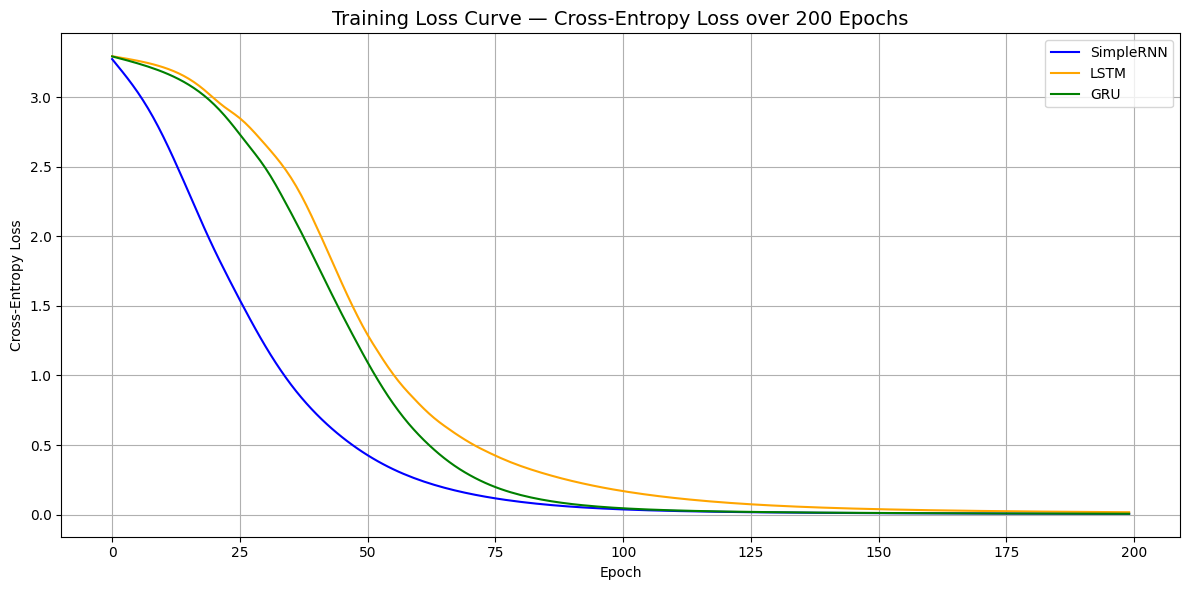

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(history_rnn.history['loss'],  label='SimpleRNN', color='blue')
plt.plot(history_lstm.history['loss'], label='LSTM',      color='orange')
plt.plot(history_gru.history['loss'],  label='GRU',       color='green')
plt.title('Training Loss Curve — Cross-Entropy Loss over 200 Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#  Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [19]:
def generate_text(model, seed_text, next_words=10):
    """
    Generate next_words words from a given seed_text using np.argmax
    over next-word probability arrays.
    """
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list],
                                   maxlen=max_sequence_len - 1,
                                   padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

##  Generate Text Samples

In [20]:
seed_phrase = "python is"

print("\n Generated Text Samples (seed: '{}')".format(seed_phrase))
print("=" * 60)

rnn_output  = generate_text(model_rnn,  seed_phrase, next_words=10)
lstm_output = generate_text(model_lstm, seed_phrase, next_words=10)
gru_output  = generate_text(model_gru,  seed_phrase, next_words=10)

print(f"SimpleRNN → {rnn_output}")
print(f"LSTM      → {lstm_output}")
print(f"GRU       → {gru_output}")


 Generated Text Samples (seed: 'python is')
SimpleRNN → python is a popular programming language programming language language language language language
LSTM      → python is a popular programming language language language language tasks language language
GRU       → python is a popular programming language language language language errors language language


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**